# Cats vs Dogs Classification using ResNet50V2 Transfer Learning

In this notebook, a deep learning model is developed to classify images of cats and dogs using Transfer Learning with ResNet50V2. The Cats vs Dogs dataset is loaded and divided into training and validation sets. The images are then preprocessed using the ResNet50V2 preprocessing function to ensure compatibility with the pretrained ImageNet weights.

A pretrained ResNet50V2 model is used as the feature extraction backbone with the top classification layer removed. Custom classification layers are added to adapt the model to the binary classification task. During the feature extraction phase, the pretrained ResNet50V2 layers remain frozen while only the newly added classification layers are trained.

After evaluating the feature extraction model, fine-tuning is performed by unfreezing selected layers of ResNet50V2 and retraining the model using a smaller learning rate. This allows the pretrained network to adapt its learned features to the Cats vs Dogs dataset and improve classification performance.

Finally, the model is evaluated using validation accuracy and loss metrics. The trained weights are saved, and the results are compared with other transfer learning architectures such as MobileNetV2 and EfficientNetB0 to determine the most suitable backbone for deployment and future projects.


In [ ]:
!pip install -U protobuf

In [ ]:
!pip install protobuf==6.31.1
!pip install --upgrade tensorflow-datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.1/321.1 kB 8.1 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.35.1
    Uninstalling protobuf-7.35.1:
      Successfully uninstalled protobuf-7.35.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.31.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.31.1 which is incompatible.


In [ ]:
!pip install -U protobuf==6.31.1

In [ ]:
import tensorflow as tf
import keras

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.20.0
Keras: 3.13.2


In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [ ]:
(train_ds, val_ds), info = tfds.load(
    "cats_vs_dogs",
    split=["train[:80%]", "train[80%:]"],
    as_supervised=True,
    with_info=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.H1JY6H_4.0.1/cats_vs_dogs-train.tfrecord-[0-9][0-9…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [ ]:
IMG_SIZE = (160, 160)

def resize(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    return image, label

train_ds = train_ds.map(resize)
val_ds = val_ds.map(resize)

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.batch(32).prefetch(AUTOTUNE)
val_ds = val_ds.batch(32).prefetch(AUTOTUNE)

In [ ]:
base = tf.keras.applications.ResNet50V2(
    input_shape=(160,160,3),
    include_top=False,
    weights='imagenet'
)

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
inputs = tf.keras.Input(shape=(160, 160, 3))

x = tf.keras.applications.resnet_v2.preprocess_input(inputs)

x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 188s 226ms/step - accuracy: 0.8818 - loss: 0.2819 - val_accuracy: 0.6528 - val_loss: 0.7528
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 98s 168ms/step - accuracy: 0.9238 - loss: 0.1889 - val_accuracy: 0.9065 - val_loss: 0.2297
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 142s 168ms/step - accuracy: 0.9394 - loss: 0.1456 - val_accuracy: 0.9076 - val_loss: 0.2674
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 98s 168ms/step - accuracy: 0.9551 - loss: 0.1175 - val_accuracy: 0.8998 - val_loss: 0.2378
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 98s 168ms/step - accuracy: 0.9632 - loss: 0.0960 - val_accuracy: 0.9437 - val_loss: 0.1505
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 98s 168ms/step - accuracy: 0.9685 - loss: 0.0783 - val_accuracy: 0.9132 - val_loss: 0.2453
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 98s 168ms/step - accuracy: 0.9724 - loss: 0.0751 - val_accuracy: 0.9336 - val_loss: 0.1822
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 98s 169ms/step - accuracy: 0.9809 - loss:

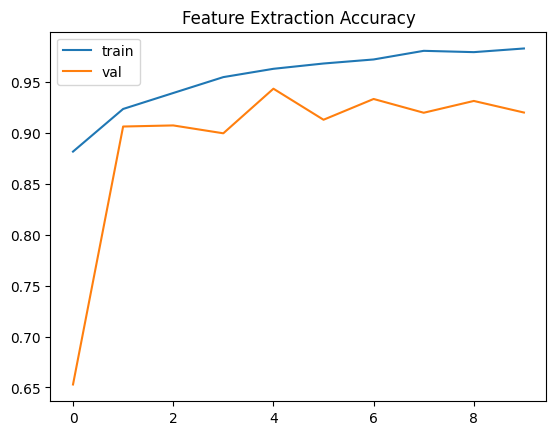

In [ ]:
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.legend()
plt.title("Feature Extraction Accuracy")
plt.show()

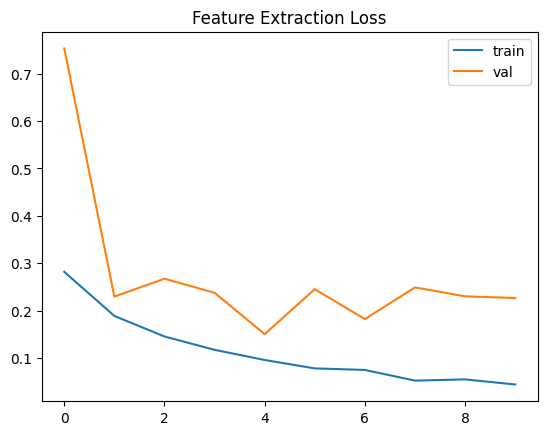

In [ ]:
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.legend()
plt.title("Feature Extraction Loss")
plt.show()

In [ ]:
loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:", acc)

146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.9202 - loss: 0.2267
Validation Accuracy: 0.920249342918396


In [ ]:
model.save_weights("resnet50_weights.weights.h5")

In [ ]:
!ls -lh

total 270M
-rw-r--r-- 1 root root 270M Jun 16 06:36 resnet50_weights.weights.h5
drwxr-xr-x 1 root root 4.0K Jun  4 13:39 sample_data


# Cats vs Dogs — Fine-Tuning Phase (Transfer Learning)

## Today's Goal
In this phase, we improve the previously trained feature extraction model by unfreezing the top layers of the MobileNetV2 base model and fine-tuning it with a very small learning rate (1e-5). This allows the pretrained model to adapt slightly to the Cats vs Dogs dataset without destroying learned ImageNet features.

---

## Steps Followed

1. Loaded the previously saved feature extraction model (`cats_dogs_feature_extraction.keras`).
2. Retrieved the MobileNetV2 base model from the architecture.
3. Unfroze only the last ~30 layers of the base model while keeping earlier layers frozen.
4. Recompiled the model using a very small learning rate (`1e-5`) to avoid disrupting pretrained weights.
5. Trained the model for additional epochs on the same dataset.
6. Monitored training and validation accuracy to evaluate improvement over feature extraction phase.
7. Saved the final fine-tuned model as `cats_dogs_finetuned.keras`.

---

## Key Concept
Fine-tuning allows the pretrained model to adjust high-level features to better fit the target dataset. This step usually improves accuracy beyond the feature extraction stage.

---

## Expected Outcome
- Higher validation accuracy than feature extraction phase (~90% → ~92–93%)
- Better generalization on unseen images
- Slight reduction in training-validation gap

In [ ]:
import tensorflow as tf

# The model architecture was defined in previous cells (e.g., 0ctjdcuselsx).
# We are loading the weights saved after the feature extraction phase.
model.load_weights("resnet50_weights.weights.h5")

In [ ]:
base_model = model.layers[1]  # sometimes index may differ, adjust if needed

base_model.trainable = True

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # VERY SMALL LR
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 75s 101ms/step - accuracy: 0.9667 - loss: 0.0886 - val_accuracy: 0.9319 - val_loss: 0.1957
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 48s 83ms/step - accuracy: 0.9710 - loss: 0.0765 - val_accuracy: 0.9342 - val_loss: 0.1903
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 81s 82ms/step - accuracy: 0.9723 - loss: 0.0736 - val_accuracy: 0.9357 - val_loss: 0.1872
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 82s 82ms/step - accuracy: 0.9728 - loss: 0.0706 - val_accuracy: 0.9362 - val_loss: 0.1847
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 47s 81ms/step - accuracy: 0.9735 - loss: 0.0687 - val_accuracy: 0.9357 - val_loss: 0.1827
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 47s 80ms/step - accuracy: 0.9756 - loss: 0.0661 - val_accuracy: 0.9364 - val_loss: 0.1813
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 51s 87ms/step - accuracy: 0.9759 - loss: 0.0644 - val_accuracy: 0.9357 - val_loss: 0.1801
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 51s 88ms/step - accuracy: 0.9765 - loss: 0.0628 -

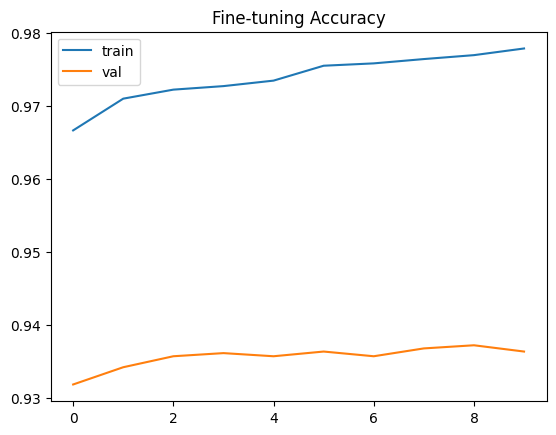

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_fine.history["accuracy"], label="train")
plt.plot(history_fine.history["val_accuracy"], label="val")
plt.legend()
plt.title("Fine-tuning Accuracy")
plt.show()

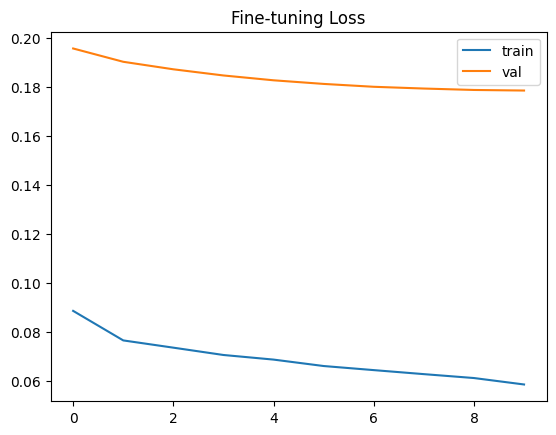

In [ ]:
plt.plot(history_fine.history["loss"], label="train")
plt.plot(history_fine.history["val_loss"], label="val")
plt.legend()
plt.title("Fine-tuning Loss")
plt.show()

In [ ]:
loss, acc = model.evaluate(val_ds)
print("Final Validation Accuracy:", acc)

146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.9364 - loss: 0.1785
Final Validation Accuracy: 0.9363714456558228


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━

In [ ]:
import matplotlib.pyplot as plt

wrong_images = []
wrong_labels = []
wrong_preds = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)

    for i in range(len(labels)):
        if preds[i] != labels[i]:
            wrong_images.append(images[i].numpy())
            wrong_labels.append(labels[i].numpy())
            wrong_preds.append(preds[i])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/ste